<div style="text-align: center;">

# Sustainability Aware Asset Management  
# Portfolio Allocation with a Carbon Objective  

<br>

**Course:** Sustainability Aware Asset Management<br>
**Instructor:** Professor Eric Jondeau<br> 
**Academic Year:** 2025–2026<br>  

<br>

**Group Members**  
Matteo Piras<br>
Tomas Papuga<br> 
Marco d'Amico<br>
Roberto Berardi<br> 

<br>

**Submission Date:** May 2026  

</div>

# Part I- Standard Portfolio Allocation
## 1) Data Cleaning

### Missing Prices and Datastream Error Rows

The raw datasets are direct exports from Datastream and may contain structural inconsistencies that must be addressed before any financial analysis.

Some ISIN codes are flagged with `$$ER`, indicating that Datastream could not correctly match the requested security (for example, due to share class mismatches or unavailable data). These rows do not contain valid financial information and are therefore removed from all datasets.

We then standardize the structure of each file by:
- Converting ISIN codes to a consistent string format,
- Removing non-numeric columns such as firm names,
- Transposing the data so that dates form the index and firms form the columns,
- Converting all values to numeric format.

At this stage, we only correct structural and data-quality issues. No economic filtering (region, carbon availability, liquidity, etc.) is applied yet. 

In [5]:
import pandas as pd
import numpy as np

print("Starting finalized data preparation process...")

# --------------------------------------------------------
# 1. Setup and Static Data Filtering
# --------------------------------------------------------
# Load the static dataset to identify the initial investment universe
static_df = pd.read_excel('Data_2026/Static_2025.xlsx')
static_df['ISIN'] = static_df['ISIN'].astype(str).str.strip()

# Isolate firms belonging to the Emerging Markets (EM) region
em_firms = static_df[static_df['Region'] == 'EM'].copy()
valid_em_isins = em_firms['ISIN'].unique().tolist()

def load_and_transpose(filepath, is_monthly=False):
    """
    Standardizes Datastream Excel exports into time-series DataFrames.
    Removes error flags ($$ER) and transposes firms to columns.
    """
    df = pd.read_excel(filepath)
    # Rule: Explicitly delete ISINs with Datastream errors ($$ER)
    df = df[~df['ISIN'].astype(str).str.contains(r'\$\$ER', na=False)]
    df['ISIN'] = df['ISIN'].astype(str).str.strip()
    df.set_index('ISIN', inplace=True)
    
    if 'NAME' in df.columns:
        df.drop(columns=['NAME'], inplace=True)
    
    df_t = df.T
    df_t = df_t.apply(pd.to_numeric, errors='coerce')
    
    # Handle indexing based on data frequency (Monthly for RI, Yearly for Carbon)
    if is_monthly:
        df_t.index = pd.to_datetime(df_t.index)
    else:
        df_t.index = df_t.index.astype(int)
    return df_t

print("Static data loaded and EM firms identified.")

Starting finalized data preparation process...
Static data loaded and EM firms identified.


### Missing Values: Beginning, Middle, and End of Sample

The datasets contain different types of missing observations that must be handled carefully to ensure consistent return estimation and avoid distortions in portfolio construction.

First, missing values at the beginning of the sample typically correspond to firms that were not yet listed or had not started reporting data. In this case, no correction is applied.

Second, missing values between two available observations usually reflect temporary reporting gaps or data issues. To preserve continuity in the return series, we apply a forward-fill procedure to bridge these internal gaps.

Third, missing values at the end of the sample generally correspond to firm delisting or default events. In such cases, the price is assumed to drop to zero, implying a realized return of −100% in the month following the last valid observation. All subsequent periods are set to missing values to avoid artificially lowering volatility.

This treatment ensures a realistic handling of firm exits while maintaining the integrity of the historical return series.

In [6]:
# --------------------------------------------------------
# 2. Return Index (RI) Processing with Delisting Logic
# --------------------------------------------------------
ri_monthly = load_and_transpose('Data_2026/DS_RI_T_USD_M_2025.xlsx', is_monthly=True)
ri_em = ri_monthly[[isin for isin in valid_em_isins if isin in ri_monthly.columns]].copy()

# Rule: Treat prices < 0.5 as missing values to avoid extreme returns from penny stocks
ri_em[ri_em < 0.5] = np.nan

# CRITICAL: Identify the real last valid date BEFORE filling gaps.
# This ensures that delisting (final disappearance) is not masked by forward-filling.
real_last_valid_dates = ri_em.apply(lambda col: col.last_valid_index())

# Rule: Fill gaps between available values (Forward Fill) to bridge misreporting
ri_em_filled = ri_em.ffill()
returns_em = ri_em_filled.pct_change()

# Applying Precise Delisting Logic: -100% loss followed by NaNs
for isin in returns_em.columns:
    last_date = real_last_valid_dates[isin]
    if pd.notna(last_date):
        last_pos = returns_em.index.get_loc(last_date)
        
        # If the firm disappears before the end of the sample, acknowledge the loss
        if last_pos < len(returns_em) - 1:
            # Force -100% return in the month following the last valid price
            returns_em.iloc[last_pos + 1, returns_em.columns.get_loc(isin)] = -1.0
            
            # Ensure post-delisting periods are NaN (not zero) to avoid stale price/low volatility bias
            if last_pos + 1 < len(returns_em) - 1:
                returns_em.iloc[last_pos + 2:, returns_em.columns.get_loc(isin)] = np.nan
    else:
        # Mark firms with no valid data for complete removal
        returns_em[isin] = np.nan

/var/folders/4n/jt__gj0d3ksb2wstq618k30m0000gn/T/ipykernel_67624/3561478211.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_em = ri_em_filled.pct_change()


### Carbon Data Preparation and Validation

Scope 1 and Scope 2 carbon emissions data are first loaded from the Datastream files and transformed into annual time-series format. The sample is then restricted to firms belonging to the Emerging Markets universe.

To account for reporting gaps across years, carbon emissions data are forward-filled. This means that when a firm does not report emissions in a given year, the most recent available observation is carried forward.

After this step, firms with no available data at all are removed from the corresponding datasets. The same cleaning rule is also applied to the returns matrix, so that firms without usable information are excluded from the analysis.

Finally, a validation summary is printed to check the dimensions of the returns, Scope 1, and Scope 2 datasets before proceeding with the next steps.

In [7]:

scope1_em = load_and_transpose('Data_2026/DS_CO2_SCOPE_1_Y_2025.xlsx', is_monthly=False)
scope2_em = load_and_transpose('Data_2026/DS_CO2_SCOPE_2_Y_2025.xlsx', is_monthly=False)

# Filter for EM and apply Forward Fill for reporting gaps between years
scope1_em = scope1_em[[isin for isin in valid_em_isins if isin in scope1_em.columns]].copy().ffill()
scope2_em = scope2_em[[isin for isin in valid_em_isins if isin in scope2_em.columns]].copy().ffill()

# Rule: Physically delete firms with no associated data from all tables
returns_em.dropna(how='all', axis=1, inplace=True)
scope1_em.dropna(how='all', axis=1, inplace=True)
scope2_em.dropna(how='all', axis=1, inplace=True)

print("Data Validation Overview:")
print(f"- Returns Matrix: {returns_em.shape[0]} months, {returns_em.shape[1]} firms")
print(f"- Scope 1/2 Matrices: {scope1_em.shape[0]} years")
display(returns_em.head())

Data Validation Overview:
- Returns Matrix: 314 months, 668 firms
- Scope 1/2 Matrices: 27 years


ISIN,ARALUA010258,ARP125991090,ARSIDE010029,BMG211591018,BRABEVACNOR1,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4,...,ZAE000117321,ZAE000127148,ZAE000134961,ZAE000170049,ZAE000179420,ZAE000191342,ZAE000255915,ZAE000298253,ZAE000302618,ZAE000322095
1999-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-31,0.176511,-0.051861,-0.004877,NaN,-0.044175,-0.067245,0.023986,-0.249634,0.011906,NaN,...,-0.115161,-0.049527,0.096965,0.067794,0.205596,0.099568,-0.080722,0.125341,0.021174,-0.114179
2000-02-29,0.050002,0.178923,0.039543,NaN,-0.045539,-0.036328,-0.107794,0.005452,0.043492,NaN,...,-0.037800,-0.100608,-0.326248,0.028928,-0.053481,-0.084315,-0.062844,-0.181598,0.018379,-0.023150
2000-03-31,-0.023552,-0.105072,-0.002113,NaN,0.313941,-0.130625,0.152061,0.014002,0.002361,NaN,...,-0.067887,-0.034040,-0.044066,-0.176088,-0.126866,0.073915,-0.054382,-0.038462,-0.142989,-0.104274
2000-04-28,-0.016173,-0.161842,-0.071188,NaN,-0.001350,-0.077311,-0.108617,-0.032966,-0.020143,NaN,...,-0.034586,-0.042240,-0.172342,-0.129131,-0.035409,-0.208833,-0.030503,-0.224615,-0.095572,0.003496


### Dynamic Investment Set Construction (10-Year Rolling Window)

After cleaning the data, we construct the investment universe dynamically for each portfolio formation year.

For each year 
𝑌
Y, we use a 10-year rolling estimation window (from January 
𝑌
−
9
Y−9 to December 
𝑌
Y) to determine firm eligibility. The portfolio formed at the end of year 
𝑌
Y is implemented during year 
𝑌
+
1
Y+1.

A firm is included in the investment set only if it satisfies all of the following conditions:

Price availability at formation date:
The firm must have a valid price at the end of year 
𝑌
Y. Firms with missing or invalid prices at the portfolio formation date are excluded.

Liquidity condition (stale price filter):
Over the 10-year estimation window, the proportion of zero monthly returns must not exceed 50%. This ensures that illiquid firms do not artificially reduce estimated portfolio volatility.

Carbon data availability:
Both Scope 1 and Scope 2 emissions data must be available at the end of year 
𝑌
Y. This guarantees consistency between the financial allocation and the sustainability analysis.

The resulting set of eligible firms is stored for each holding year 
𝑌
+
1
Y+1, forming a sequence of dynamically updated investment universes.

In [8]:
print("Initiating dynamic filtering for 10-year rolling windows...")

# Step 5: Dynamic Universe Construction
# We identify eligible firms for each year based on historical liquidity and ESG disclosure.
valid_investment_sets = {}
estimation_years = range(2009, 2025)

for Y in estimation_years:
    # Define the 10-year rolling estimation window (Dec Y-9 to Dec Y)
    start_date, end_date = f"{Y-9}-01-01", f"{Y}-12-31"
    window_returns = returns_em.loc[start_date:end_date]
    window_prices = ri_em.loc[start_date:end_date]
    
    valid_isins_for_year = []
    
    for isin in returns_em.columns:
        # Rule: Price Availability at end of year Y
        # Exclude firms missing a valid price (>0.5 USD) at the portfolio formation date.
        if pd.isna(window_prices[isin].iloc[-1]):
            continue
            
        # Rule: Stale Price / Liquidity Filter
        # Calculate the ratio of months with zero returns to avoid illiquid assets.
        total_valid_months = window_returns[isin].notna().sum()
        if total_valid_months < 36:
            continue
        
        # Exclude if the firm has no price movement for > 50% of the window.
        if (window_returns[isin] == 0.0).sum() / total_valid_months > 0.5:
            continue
            
        # Rule: Carbon Data Availability for Year Y
        # Both Scope 1 and Scope 2 data must be present for the firm to be eligible.
        if Y in scope1_em.index and Y in scope2_em.index:
            if isin in scope1_em.columns and isin in scope2_em.columns:
                if not pd.isna(scope1_em.loc[Y, isin]) and not pd.isna(scope2_em.loc[Y, isin]):
                    valid_isins_for_year.append(isin)
    
    # Store the investment set for the subsequent holding period (Y + 1)
    valid_investment_sets[Y + 1] = valid_isins_for_year
    print(f"Holding Year {Y+1}: {len(valid_isins_for_year)} firms identified.")

print("\nInvestment universes constructed successfully.")

Initiating dynamic filtering for 10-year rolling windows...
Holding Year 2010: 66 firms identified.
Holding Year 2011: 160 firms identified.
Holding Year 2012: 198 firms identified.
Holding Year 2013: 224 firms identified.
Holding Year 2014: 245 firms identified.
Holding Year 2015: 267 firms identified.
Holding Year 2016: 297 firms identified.
Holding Year 2017: 334 firms identified.
Holding Year 2018: 381 firms identified.
Holding Year 2019: 416 firms identified.
Holding Year 2020: 463 firms identified.
Holding Year 2021: 504 firms identified.
Holding Year 2022: 542 firms identified.
Holding Year 2023: 571 firms identified.
Holding Year 2024: 579 firms identified.
Holding Year 2025: 566 firms identified.

Investment universes constructed successfully.


In [9]:
print("Calculating Expected Returns and Covariance Matrices...")

# --------------------------------------------------------
# 6. Estimation of Expected Returns and Covariance Matrices
# --------------------------------------------------------
# Using the formulas exactly:
#
# mu_hat_Y = (1/tau) * sum R_t
#
# Sigma_Y = (1/tau) * sum (R_t - mu_hat_Y)'(R_t - mu_hat_Y)
#
# Missing values are replaced by 0 before computation.

mu_estimates = {}
sigma_estimates = {}

estimation_years = range(2009, 2025)

for Y in estimation_years:

    holding_year = Y + 1
    valid_isins = valid_investment_sets[holding_year]

    if len(valid_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    # 10-year estimation window
    start_date, end_date = f"{Y-9}-01-01", f"{Y}-12-31"

    window_returns = returns_em.loc[start_date:end_date, valid_isins].copy()

    # Replace missing returns with 0
    window_returns = window_returns.fillna(0)

    # number of observations (should be 120 months)
    tau = window_returns.shape[0]

    # --------------------------------------------------------
    # Expected Returns (formula)
    # --------------------------------------------------------
    mu_hat_Y = window_returns.sum(axis=0) / tau

    # --------------------------------------------------------
    # Covariance Matrix (formula)
    # --------------------------------------------------------
    R = window_returns.to_numpy()            # tau x N
    mu = mu_hat_Y.to_numpy().reshape(1, -1)  # 1 x N

    # center returns
    R_centered = R - mu

    # covariance formula
    Sigma_array = (R_centered.T @ R_centered) / tau

    # convert back to dataframe
    Sigma_Y = pd.DataFrame(
        Sigma_array,
        index=window_returns.columns,
        columns=window_returns.columns
    )

    mu_estimates[holding_year] = mu_hat_Y
    sigma_estimates[holding_year] = Sigma_Y

    print(
        f"Holding Year {holding_year}: "
        f"{len(valid_isins)} firms, "
        f"tau={tau}, "
        f"mu size={mu_hat_Y.shape[0]}, "
        f"Sigma shape={Sigma_Y.shape}"
    )

print("\nExpected returns and covariance matrices computed successfully.")

# --------------------------------------------------------
# Example check
# --------------------------------------------------------
example_year = 2014
if example_year in mu_estimates and example_year in sigma_estimates:
    print(f"\nExample: Holding Year {example_year}")
    display(mu_estimates[example_year].head())
    display(sigma_estimates[example_year].iloc[:5, :5])

Calculating Expected Returns and Covariance Matrices...
Holding Year 2010: 66 firms, tau=120, mu size=66, Sigma shape=(66, 66)
Holding Year 2011: 160 firms, tau=120, mu size=160, Sigma shape=(160, 160)
Holding Year 2012: 198 firms, tau=120, mu size=198, Sigma shape=(198, 198)
Holding Year 2013: 224 firms, tau=120, mu size=224, Sigma shape=(224, 224)
Holding Year 2014: 245 firms, tau=120, mu size=245, Sigma shape=(245, 245)
Holding Year 2015: 267 firms, tau=120, mu size=267, Sigma shape=(267, 267)
Holding Year 2016: 297 firms, tau=120, mu size=297, Sigma shape=(297, 297)
Holding Year 2017: 334 firms, tau=120, mu size=334, Sigma shape=(334, 334)
Holding Year 2018: 381 firms, tau=120, mu size=381, Sigma shape=(381, 381)
Holding Year 2019: 416 firms, tau=120, mu size=416, Sigma shape=(416, 416)
Holding Year 2020: 463 firms, tau=120, mu size=463, Sigma shape=(463, 463)
Holding Year 2021: 504 firms, tau=120, mu size=504, Sigma shape=(504, 504)
Holding Year 2022: 542 firms, tau=120, mu size=5

ISIN
BRBBASACNOR3    0.024255
BRBBDCACNPR8    0.022722
BRBRFSACNOR8    0.032435
BRBRKMACNPA4    0.015174
BRCESPACNPB4    0.011178
dtype: float64

ISIN,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4
ISIN,,,,,
BRBBASACNOR3,0.015590,0.010866,0.008129,0.007731,0.006893
BRBBDCACNPR8,0.010866,0.012099,0.008446,0.007131,0.005413
BRBRFSACNOR8,0.008129,0.008446,0.014663,0.006491,0.005183
BRBRKMACNPA4,0.007731,0.007131,0.006491,0.019695,0.004748
BRCESPACNPB4,0.006893,0.005413,0.005183,0.004748,0.014449


In [10]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

print("Building Minimum-Variance Portfolio (Out-of-Sample), long-only...")

# --------------------------------------------------------
# 2.2 Minimum-variance portfolio (PDF)
# --------------------------------------------------------
# Rebalance each year: end of Y -> hold year (Y+1)
holding_years = range(2014, 2026)   # hold 2014..2025

weights_mv = {}          # weights decided at end of Y, used for holding year H
mv_oos_returns_list = [] # list of monthly return series for each holding year


# -------------------------
# Helper 1: solve long-only min-variance weights
# min w'Σw s.t. sum(w)=1, w>=0
# -------------------------
def solve_min_var_long_only(Sigma_df: pd.DataFrame) -> pd.Series:
    assets = Sigma_df.columns.tolist()
    S = Sigma_df.to_numpy()
    n = len(assets)

    def objective(w):
        return float(w @ S @ w)

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * n
    w0 = np.ones(n) / n

    res = minimize(objective, w0, method="SLSQP", bounds=bounds, constraints=constraints)

    if not res.success:
        raise RuntimeError(f"Min-variance optimization failed: {res.message}")

    return pd.Series(res.x, index=assets)


# -------------------------
# Helper 2: compute monthly portfolio returns with PDF weight drift inside the year
# Rp,t = alpha_{t-1}' R_t
# alpha_{i,t} = alpha_{i,t-1} * (1+R_{i,t}) / (1+Rp,t)
# -------------------------
def holding_year_returns_with_drift(hold_returns: pd.DataFrame, w_start: pd.Series) -> pd.Series:
    # Ensure same asset order
    hold_returns = hold_returns[w_start.index].copy()

    # PDF-style: if missing returns, set to 0 so the month is still computed
    hold_returns = hold_returns.fillna(0)

    w = w_start.copy()
    out = []

    for date, r in hold_returns.iterrows():
        # portfolio return using weights at start of month
        rp = float((w * r).sum())
        out.append((date, rp))

        # drift update for next month
        denom = 1.0 + rp
        if denom <= 0:
            # portfolio hit -100% => cannot update further
            break

        w = w * (1.0 + r) / denom

        # numeric cleanup: keep long-only and fully invested
        w = w.clip(lower=0.0)
        s = float(w.sum())
        if s > 0:
            w = w / s

    return pd.Series(dict(out)).sort_index()


# --------------------------------------------------------
# Main loop: each holding year H uses Sigma estimated at end of (H-1)
# --------------------------------------------------------
for H in holding_years:
    # Need investment set for holding year H
    if H not in valid_investment_sets:
        print(f"Holding Year {H}: missing investment set -> skipped")
        continue

    isins = valid_investment_sets[H]
    if len(isins) == 0:
        print(f"Holding Year {H}: no eligible firms -> skipped")
        continue

    # Need Sigma for holding year H (estimated at end of Y=H-1)
    if H not in sigma_estimates:
        print(f"Holding Year {H}: missing Sigma -> skipped")
        continue

    Sigma_H = sigma_estimates[H].copy()

    # IMPORTANT: Sigma must match the assets we invest in (intersection)
    common_assets = [c for c in isins if c in Sigma_H.columns]
    Sigma_H = Sigma_H.loc[common_assets, common_assets]

    if Sigma_H.shape[0] < 2:
        print(f"Holding Year {H}: too few assets after alignment -> skipped")
        continue

    # Solve MV weights (end of Y, used for holding year H)
    w_start = solve_min_var_long_only(Sigma_H)
    weights_mv[H] = w_start

    # Holding period monthly returns (Jan..Dec of H)
    hold_start, hold_end = f"{H}-01-01", f"{H}-12-31"
    hold_ret = returns_em.loc[hold_start:hold_end, w_start.index].copy()

    # Compute portfolio returns month-by-month with drift update
    rp_H = holding_year_returns_with_drift(hold_ret, w_start)
    mv_oos_returns_list.append(rp_H)

    print(f"Holding Year {H}: assets={len(w_start)}, months={len(rp_H)}")

# Concatenate all holding years
if len(mv_oos_returns_list) == 0:
    raise ValueError("No out-of-sample returns produced (mv_oos_returns_list is empty). Check Sigma/investment sets alignment.")

mv_oos = pd.concat(mv_oos_returns_list).sort_index()
mv_oos.name = "MV_OOS"

print("\nMV out-of-sample return series:")
print("Length:", len(mv_oos))
print("First / last:", mv_oos.index.min(), "to", mv_oos.index.max())
display(mv_oos.head())


# --------------------------------------------------------
# Performance statistics (PDF asks: annualized mean, vol, Sharpe, min, max)
# --------------------------------------------------------
# Sharpe: if you have a monthly risk-free series available, use it; otherwise assume rf=0.
rf_series = None
for candidate in ["rf_monthly", "risk_free_monthly", "rf", "risk_free"]:
    if candidate in globals():
        rf_series = globals()[candidate]
        break

if rf_series is not None:
    rf_series = pd.Series(rf_series).copy()
    rf_series.index = pd.to_datetime(rf_series.index)
    rf_series = rf_series.reindex(mv_oos.index).fillna(0)
    excess = mv_oos - rf_series
else:
    excess = mv_oos

mu_annual = mv_oos.mean() * 12
vol_annual = mv_oos.std(ddof=0) * np.sqrt(12)   # ddof=0 to keep “population-style” consistency
sharpe = (excess.mean() * 12) / (excess.std(ddof=0) * np.sqrt(12)) if excess.std(ddof=0) > 0 else np.nan

stats_mv = {
    "annualized_mean": float(mu_annual),
    "annualized_vol": float(vol_annual),
    "sharpe_ratio": float(sharpe),
    "min_monthly": float(mv_oos.min()),
    "max_monthly": float(mv_oos.max()),
}

print("\nMV (OOS) summary statistics:")
for k, v in stats_mv.items():
    print(f"- {k}: {v}")

Building Minimum-Variance Portfolio (Out-of-Sample), long-only...
Holding Year 2014: assets=245, months=12
Holding Year 2015: assets=267, months=12
Holding Year 2016: assets=297, months=12
Holding Year 2017: assets=334, months=12
Holding Year 2018: assets=381, months=12
Holding Year 2019: assets=416, months=12
Holding Year 2020: assets=463, months=12
Holding Year 2021: assets=504, months=12
Holding Year 2022: assets=542, months=12
Holding Year 2023: assets=571, months=12
Holding Year 2024: assets=579, months=12
Holding Year 2025: assets=566, months=12

MV out-of-sample return series:
Length: 144
First / last: 2014-01-31 00:00:00 to 2025-12-31 00:00:00


2014-01-31   -0.035380
2014-02-28    0.020810
2014-03-31    0.016481
2014-04-30    0.027703
2014-05-30    0.005546
Name: MV_OOS, dtype: float64


MV (OOS) summary statistics:
- annualized_mean: 0.06511870027399333
- annualized_vol: 0.10875578183196827
- sharpe_ratio: 0.5987608123180443
- min_monthly: -0.06461910353116797
- max_monthly: 0.12160859991421102


Building Value-Weighted (Benchmark) Portfolio + comparing to MV (PDF calendar, Sharpe uses MONTHLY RF from Excel)...
Market cap loaded:
cap_em shape: (314, 702)


ISIN,ARALUA010258,ARP125991090,ARSIDE010029,BMG211591018,BRABEVACNOR1,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4,...,ZAE000117321,ZAE000127148,ZAE000134961,ZAE000170049,ZAE000179420,ZAE000191342,ZAE000255915,ZAE000298253,ZAE000302618,ZAE000322095
1999-12-31,1129.31,1656.30,1414.37,NaN,898.33,1869.60,4233.93,168.22,378.10,NaN,...,2823.19,1543.36,965.18,430.21,4.68,105.41,2882.25,230.57,436.66,1525.02
2000-01-31,1328.64,1570.39,1407.47,NaN,848.69,1744.22,4330.41,126.22,382.60,NaN,...,2498.08,1466.94,1059.00,459.38,5.64,115.91,2649.35,259.71,445.83,1350.98
2000-02-29,1395.07,1851.34,1463.08,NaN,810.12,1680.67,3849.25,126.78,389.65,NaN,...,2370.64,1319.33,713.59,472.66,5.34,106.13,2483.04,207.52,454.09,1319.65
2000-03-31,1362.23,1656.82,1460.01,NaN,1064.46,1438.89,4416.12,128.56,390.56,NaN,...,2209.70,1274.44,690.02,389.46,4.66,113.98,2348.10,249.66,389.04,1182.07
2000-04-30,1340.19,1388.70,1356.04,NaN,1062.92,1327.29,3920.07,124.32,382.71,NaN,...,2134.90,1191.15,571.00,339.13,4.50,90.17,2295.91,193.50,351.95,1186.24


Risk-free loaded (MONTHLY decimal, assumes Excel is monthly %):
RF length: 312
RF first/last: 2000-01-31 00:00:00 to 2025-12-31 00:00:00


,RF_raw_excel,RF_monthly_decimal
Unnamed: 0,,
2000-01-31,0.41,0.0041
2000-02-29,0.43,0.0043
2000-03-31,0.47,0.0047
2000-04-30,0.46,0.0046
2000-05-31,0.50,0.0050



VW out-of-sample return series (PDF calendar):
Length: 144
First / last: 2014-01-31 00:00:00 to 2025-12-31 00:00:00


...

2014-01-31   -0.066349
2014-02-28    0.020418
2014-03-31    0.049734
2014-04-30    0.005297
2014-05-31    0.042615
Freq: ME, Name: VW_OOS, dtype: float64


Quick check (first 5 months):


,MV,VW,RF,MV_excess,VW_excess
2014-01-31,-0.035380,-0.066349,0.0,-0.035380,-0.066349
2014-02-28,0.020810,0.020418,0.0,0.020810,0.020418
2014-03-31,0.016481,0.049734,0.0,0.016481,0.049734
2014-04-30,0.027703,0.005297,0.0,0.027703,0.005297
2014-05-31,0.005546,0.042615,0.0,0.005546,0.042615



Summary statistics (PDF calendar, 144 months, RF from Excel):


,MV_OOS,VW_OOS
annualized_mean,0.065119,0.082052
annualized_vol,0.108756,0.155069
sharpe_formula_1,0.437928,0.417037
sharpe_formula_2,0.437928,0.417037
sharpe_formula_3_geo,0.391521,0.347518
min_monthly,-0.064619,-0.167142
max_monthly,0.121609,0.134078
n_months,144.000000,144.000000


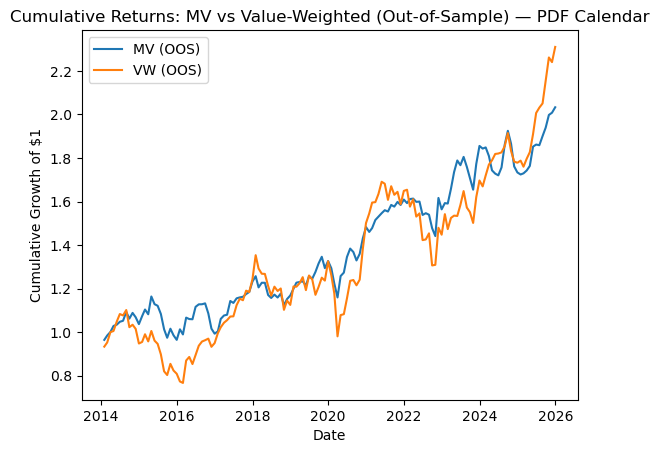

Done.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Building Value-Weighted (Benchmark) Portfolio + comparing to MV (PDF calendar, Sharpe uses MONTHLY RF from Excel)...")

# ========================================================
# 0) MARKET CAP LOADING (creates cap_em)
# ========================================================
mv_monthly = load_and_transpose('Data_2026/DS_MV_T_USD_M_2025.xlsx', is_monthly=True)

cap_em = mv_monthly[[isin for isin in valid_em_isins if isin in mv_monthly.columns]].copy()
cap_em.index = pd.to_datetime(cap_em.index)
cap_em = cap_em.sort_index()
cap_em.index = cap_em.index + pd.offsets.MonthEnd(0)
cap_em[cap_em <= 0] = np.nan

print("Market cap loaded:")
print("cap_em shape:", cap_em.shape)
display(cap_em.head())

# ========================================================
# 1) LOAD RISK-FREE (RF) — Excel format: YYYYMM as integer (e.g., 200001)
# ========================================================
rf_df = pd.read_excel("Data_2026/Risk_Free_Rate_2025.xlsx")
rf_df.columns = [str(c).strip() for c in rf_df.columns]

yyyymm_col = rf_df.columns[0]
rf_col = "RF" if "RF" in rf_df.columns else rf_df.columns[1]

rf_df[yyyymm_col] = rf_df[yyyymm_col].astype(int)
rf_dates = pd.to_datetime(rf_df[yyyymm_col].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

rf_raw = pd.Series(rf_df[rf_col].astype(float).values, index=rf_dates, name="RF_raw").sort_index()

# IMPORTANT:
# Here we assume the Excel RF is ALREADY A MONTHLY RATE IN PERCENT (common for RF datasets).
# So: 0.41 means 0.41% for that month => monthly decimal = 0.41/100
rf_monthly = rf_raw / 100.0
rf_monthly.name = "RF_monthly_decimal"

print("Risk-free loaded (MONTHLY decimal, assumes Excel is monthly %):")
print("RF length:", len(rf_monthly))
print("RF first/last:", rf_monthly.index.min(), "to", rf_monthly.index.max())
display(pd.DataFrame({"RF_raw_excel": rf_raw, "RF_monthly_decimal": rf_monthly}).head())

# ========================================================
# 2) FORCE PDF OUT-OF-SAMPLE MONTHLY CALENDAR (144 months)
# ========================================================
pdf_months = pd.date_range("2014-01-31", "2025-12-31", freq="M")

# Ensure returns_em index is datetime + month-end aligned
returns_em = returns_em.copy()
returns_em.index = pd.to_datetime(returns_em.index)
returns_em = returns_em.sort_index()
returns_em.index = returns_em.index + pd.offsets.MonthEnd(0)

# ========================================================
# 3) VALUE-WEIGHTED PORTFOLIO (PDF benchmark)
# ========================================================
vw_oos = pd.Series(index=pdf_months, dtype=float, name="VW_OOS")

for dt in pdf_months:
    H = dt.year

    isins = valid_investment_sets.get(H, [])
    if len(isins) == 0:
        vw_oos.loc[dt] = 0.0
        continue

    # returns at dt
    if dt in returns_em.index:
        r_t = returns_em.loc[dt, isins].copy()
    else:
        vw_oos.loc[dt] = 0.0
        continue

    # caps at previous month-end
    prev_dt = dt - pd.offsets.MonthEnd(1)
    if prev_dt in cap_em.index:
        cap_tminus1 = cap_em.loc[prev_dt, isins].copy()
    else:
        vw_oos.loc[dt] = 0.0
        continue

    # keep months: missing -> 0
    r_t = r_t.fillna(0.0)
    cap_tminus1 = cap_tminus1.fillna(0.0)

    total_cap = cap_tminus1.sum()
    if total_cap <= 0:
        vw_oos.loc[dt] = 0.0
        continue

    w = cap_tminus1 / total_cap
    vw_oos.loc[dt] = float((w * r_t).sum())

print("\nVW out-of-sample return series (PDF calendar):")
print("Length:", len(vw_oos))
print("First / last:", vw_oos.index.min(), "to", vw_oos.index.max())
display(vw_oos.head())

# ========================================================
# 4) ALIGN MV, VW, RF ON PDF CALENDAR + EXCESS RETURNS
# ========================================================
# MV series: force same PDF calendar too
mv_cmp = mv_oos.copy()
mv_cmp.index = pd.to_datetime(mv_cmp.index)
mv_cmp = mv_cmp.sort_index()
mv_cmp.index = mv_cmp.index + pd.offsets.MonthEnd(0)
mv_cmp = mv_cmp.reindex(pdf_months).fillna(0.0)

vw_cmp = vw_oos.reindex(pdf_months).fillna(0.0)

# RF on PDF calendar
rf_cmp = rf_monthly.reindex(pdf_months).fillna(0.0)

# Excess returns (monthly)
ex_mv = (mv_cmp - rf_cmp).rename("MV_excess")
ex_vw = (vw_cmp - rf_cmp).rename("VW_excess")

print("\nQuick check (first 5 months):")
display(pd.DataFrame({
    "MV": mv_cmp.head(),
    "VW": vw_cmp.head(),
    "RF": rf_cmp.head(),
    "MV_excess": ex_mv.head(),
    "VW_excess": ex_vw.head()
}))

# ========================================================
# 5) 3 SHARPE FORMULAS (all using MONTHLY RF)
# ========================================================
def sharpe_1_monthly_then_annual(ex: pd.Series) -> float:
    # SR = (mean(ex)/std(ex)) * sqrt(12)
    ex = ex.reindex(pdf_months).fillna(0.0)
    den = ex.std(ddof=0)
    return float((ex.mean() / den) * np.sqrt(12)) if den > 0 else np.nan

def sharpe_2_annualized_mean_and_vol(ex: pd.Series) -> float:
    # SR = (mean(ex)*12) / (std(ex)*sqrt(12))
    ex = ex.reindex(pdf_months).fillna(0.0)
    den = ex.std(ddof=0) * np.sqrt(12)
    return float((ex.mean() * 12) / den) if den > 0 else np.nan

def sharpe_3_geometric_annual_excess_over_arith_vol(ex: pd.Series) -> float:
    # SR_geo = (geo_mean_annual(excess+1) - 1) / (std(ex)*sqrt(12))
    # (Uses geometric mean for return, but volatility stays arithmetic on monthly excess)
    ex = ex.reindex(pdf_months).fillna(0.0)
    den = ex.std(ddof=0) * np.sqrt(12)
    if den <= 0:
        return np.nan
    growth = (1.0 + ex).prod()
    geo_month = growth ** (1.0 / len(ex)) - 1.0
    geo_annual = (1.0 + geo_month) ** 12 - 1.0
    return float(geo_annual / den)

def summarize_with_rf(r: pd.Series, rf: pd.Series) -> dict:
    r = r.reindex(pdf_months).fillna(0.0)
    rf = rf.reindex(pdf_months).fillna(0.0)
    ex = r - rf

    mu_annual = r.mean() * 12
    vol_annual = r.std(ddof=0) * np.sqrt(12)

    return {
        "annualized_mean": float(mu_annual),
        "annualized_vol": float(vol_annual),
        "sharpe_formula_1": sharpe_1_monthly_then_annual(ex),
        "sharpe_formula_2": sharpe_2_annualized_mean_and_vol(ex),
        "sharpe_formula_3_geo": sharpe_3_geometric_annual_excess_over_arith_vol(ex),
        "min_monthly": float(r.min()),
        "max_monthly": float(r.max()),
        "n_months": int(len(r)),
    }

stats_mv = summarize_with_rf(mv_cmp, rf_cmp)
stats_vw = summarize_with_rf(vw_cmp, rf_cmp)

comparison = pd.DataFrame({"MV_OOS": stats_mv, "VW_OOS": stats_vw})
print("\nSummary statistics (PDF calendar, 144 months, RF from Excel):")
display(comparison)

# ========================================================
# 6) PLOT CUMULATIVE RETURNS (gross, as PDF asks)
# ========================================================
cum_mv = (1 + mv_cmp).cumprod()
cum_vw = (1 + vw_cmp).cumprod()

plt.figure()
plt.plot(cum_mv.index, cum_mv.values, label="MV (OOS)")
plt.plot(cum_vw.index, cum_vw.values, label="VW (OOS)")
plt.title("Cumulative Returns: MV vs Value-Weighted (Out-of-Sample) — PDF Calendar")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.show()

print("Done.")

Building Value-Weighted (Benchmark) Portfolio + comparing to MV (PDF calendar, Sharpe uses MONTHLY RF from Excel)...
Market cap loaded:
cap_em shape: (314, 702)


ISIN,ARALUA010258,ARP125991090,ARSIDE010029,BMG211591018,BRABEVACNOR1,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4,...,ZAE000117321,ZAE000127148,ZAE000134961,ZAE000170049,ZAE000179420,ZAE000191342,ZAE000255915,ZAE000298253,ZAE000302618,ZAE000322095
1999-12-31,1129.31,1656.30,1414.37,NaN,898.33,1869.60,4233.93,168.22,378.10,NaN,...,2823.19,1543.36,965.18,430.21,4.68,105.41,2882.25,230.57,436.66,1525.02
2000-01-31,1328.64,1570.39,1407.47,NaN,848.69,1744.22,4330.41,126.22,382.60,NaN,...,2498.08,1466.94,1059.00,459.38,5.64,115.91,2649.35,259.71,445.83,1350.98
2000-02-29,1395.07,1851.34,1463.08,NaN,810.12,1680.67,3849.25,126.78,389.65,NaN,...,2370.64,1319.33,713.59,472.66,5.34,106.13,2483.04,207.52,454.09,1319.65
2000-03-31,1362.23,1656.82,1460.01,NaN,1064.46,1438.89,4416.12,128.56,390.56,NaN,...,2209.70,1274.44,690.02,389.46,4.66,113.98,2348.10,249.66,389.04,1182.07
2000-04-30,1340.19,1388.70,1356.04,NaN,1062.92,1327.29,3920.07,124.32,382.71,NaN,...,2134.90,1191.15,571.00,339.13,4.50,90.17,2295.91,193.50,351.95,1186.24


Risk-free loaded (MONTHLY decimal, assumes Excel is monthly %):
RF length: 312
RF first/last: 2000-01-31 00:00:00 to 2025-12-31 00:00:00


,RF_raw_excel,RF_monthly_decimal
Unnamed: 0,,
2000-01-31,0.41,0.0041
2000-02-29,0.43,0.0043
2000-03-31,0.47,0.0047
2000-04-30,0.46,0.0046
2000-05-31,0.50,0.0050



VW out-of-sample return series (PDF calendar):
Length: 144
First / last: 2014-01-31 00:00:00 to 2025-12-31 00:00:00


...

2014-01-31   -0.066349
2014-02-28    0.020418
2014-03-31    0.049734
2014-04-30    0.005297
2014-05-31    0.042615
Freq: ME, Name: VW_OOS, dtype: float64


Quick check (first 5 months):


,MV,VW,RF,MV_excess,VW_excess
2014-01-31,-0.035380,-0.066349,0.0,-0.035380,-0.066349
2014-02-28,0.020810,0.020418,0.0,0.020810,0.020418
2014-03-31,0.016481,0.049734,0.0,0.016481,0.049734
2014-04-30,0.027703,0.005297,0.0,0.027703,0.005297
2014-05-31,0.005546,0.042615,0.0,0.005546,0.042615



Summary statistics (PDF calendar, 144 months, RF from Excel):


,MV_OOS,VW_OOS
annualized_mean,0.065119,0.082052
annualized_vol,0.108756,0.155069
sharpe_formula_1,0.437928,0.417037
sharpe_formula_2,0.437928,0.417037
sharpe_formula_3_geo,0.391521,0.347518
min_monthly,-0.064619,-0.167142
max_monthly,0.121609,0.134078
n_months,144.000000,144.000000


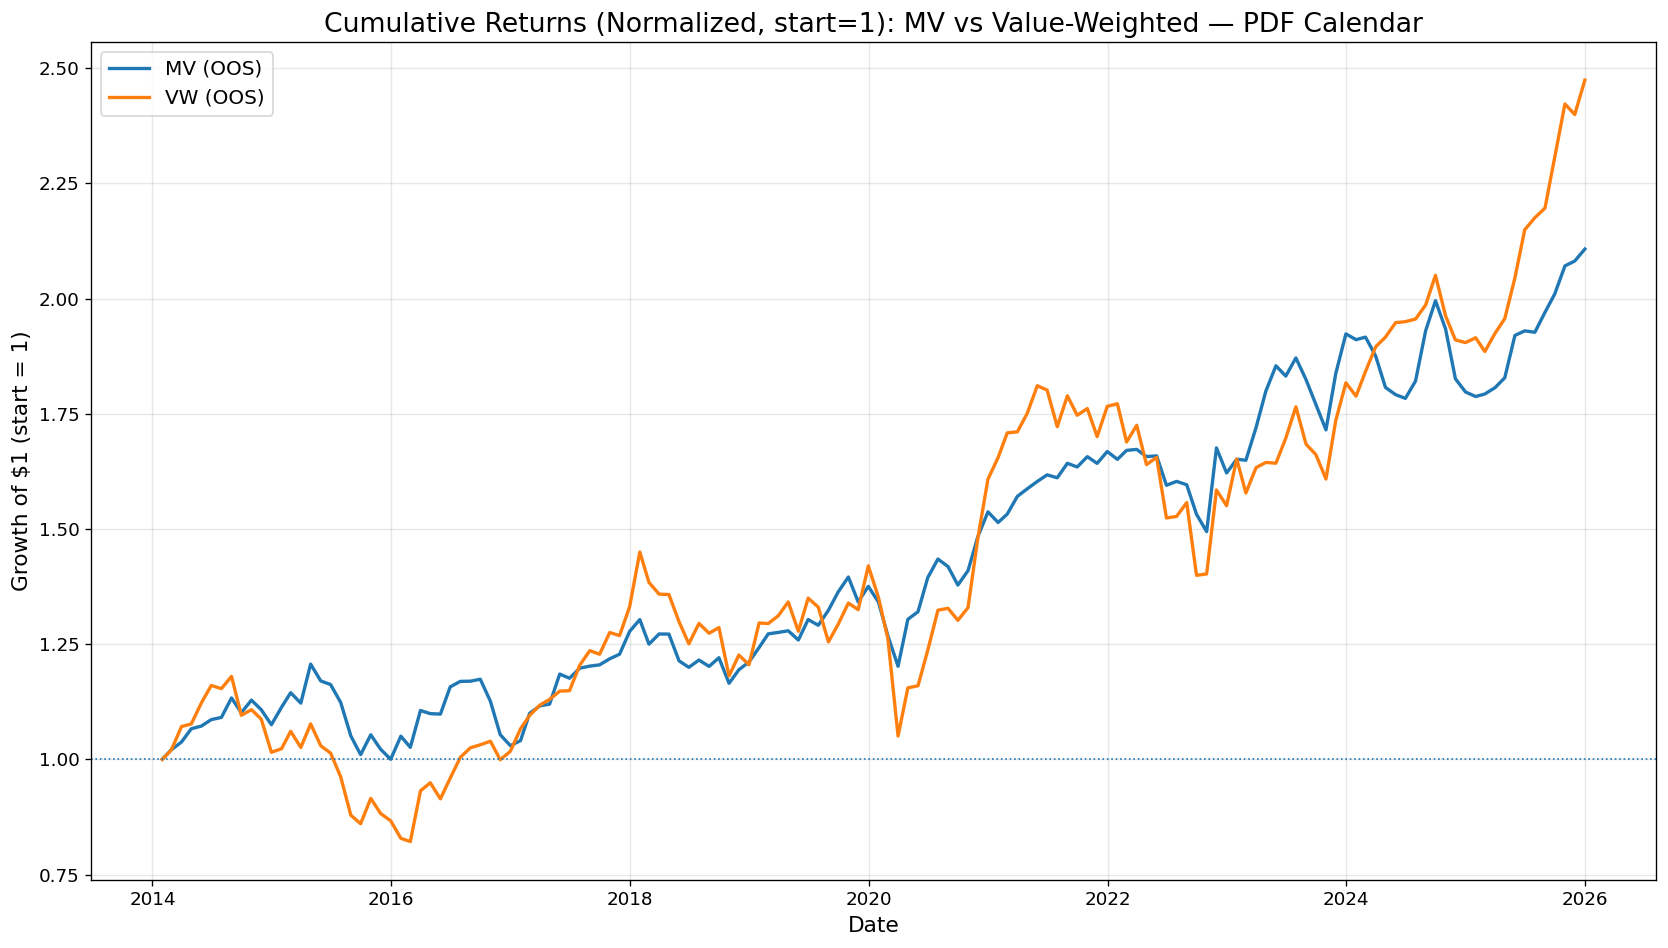

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Building Value-Weighted (Benchmark) Portfolio + comparing to MV (PDF calendar, Sharpe uses MONTHLY RF from Excel)...")

# ========================================================
# 0) HELPERS (self-contained loaders so the cell can run)
# ========================================================
def load_and_transpose(filepath, is_monthly=False):
    df = pd.read_excel(filepath)
    # drop error rows if present
    if "ISIN" in df.columns:
        df = df[~df["ISIN"].astype(str).str.contains(r"\$\$ER", na=False)]
        df["ISIN"] = df["ISIN"].astype(str).str.strip()
        df = df.set_index("ISIN")
    if "NAME" in df.columns:
        df = df.drop(columns=["NAME"])

    df_t = df.T
    df_t = df_t.apply(pd.to_numeric, errors="coerce")

    if is_monthly:
        df_t.index = pd.to_datetime(df_t.index)
    else:
        # annual index is often integer years
        try:
            df_t.index = df_t.index.astype(int)
        except:
            pass
    return df_t

def ensure_month_end_index(df):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df.index = df.index + pd.offsets.MonthEnd(0)
    return df

# ========================================================
# 1) ENSURE REQUIRED OBJECTS EXIST (auto-recover where possible)
# ========================================================

# --- returns_em must exist: cannot safely rebuild without knowing which file you used
if "returns_em" not in globals():
    raise NameError(
        "Missing `returns_em`.\n"
        "Run your earlier cell that builds monthly returns (returns_em) first."
    )

# --- valid_em_isins: if missing, try to infer from returns_em columns (best fallback)
if "valid_em_isins" not in globals():
    print("⚠️ `valid_em_isins` missing -> using returns_em.columns as fallback universe.")
    valid_em_isins = list(returns_em.columns)

# --- valid_investment_sets: cannot recreate without your PDF filtering logic (carbon availability, min obs, region)
if "valid_investment_sets" not in globals():
    raise NameError(
        "Missing `valid_investment_sets`.\n"
        "Run your Step 2.1 cell that constructs the investment set by year."
    )

# --- mv_oos: must exist if you want MV vs VW comparison
if "mv_oos" not in globals():
    raise NameError(
        "Missing `mv_oos`.\n"
        "Run your Step 2.2 cell first (minimum-variance out-of-sample returns)."
    )

# ========================================================
# 2) MARKET CAP LOADING (creates cap_em)
# ========================================================
mv_monthly = load_and_transpose("Data_2026/DS_MV_T_USD_M_2025.xlsx", is_monthly=True)

cap_em = mv_monthly[[isin for isin in valid_em_isins if isin in mv_monthly.columns]].copy()
cap_em = ensure_month_end_index(cap_em)

# optional safety: negative/zero caps make no sense for weights
cap_em[cap_em <= 0] = np.nan

print("Market cap loaded:")
print("cap_em shape:", cap_em.shape)
display(cap_em.head())

# ========================================================
# 3) LOAD RISK-FREE (RF) — Excel format: YYYYMM integer (e.g., 200001)
# ========================================================
rf_df = pd.read_excel("Data_2026/Risk_Free_Rate_2025.xlsx")
rf_df.columns = [str(c).strip() for c in rf_df.columns]

yyyymm_col = rf_df.columns[0]
rf_col = "RF" if "RF" in rf_df.columns else rf_df.columns[1]

rf_df[yyyymm_col] = rf_df[yyyymm_col].astype(int)
rf_dates = pd.to_datetime(rf_df[yyyymm_col].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

rf_raw = pd.Series(rf_df[rf_col].astype(float).values, index=rf_dates, name="RF_raw").sort_index()

# Assume Excel RF is MONTHLY percent => decimal
rf_monthly = (rf_raw / 100.0).rename("RF_monthly_decimal")

print("Risk-free loaded (MONTHLY decimal, assumes Excel is monthly %):")
print("RF length:", len(rf_monthly))
print("RF first/last:", rf_monthly.index.min(), "to", rf_monthly.index.max())
display(pd.DataFrame({"RF_raw_excel": rf_raw, "RF_monthly_decimal": rf_monthly}).head())

# ========================================================
# 4) FORCE PDF OUT-OF-SAMPLE MONTHLY CALENDAR (144 months)
# ========================================================
pdf_months = pd.date_range("2014-01-31", "2025-12-31", freq="M")

returns_em = returns_em.copy()
returns_em = ensure_month_end_index(returns_em)

# ========================================================
# 5) VALUE-WEIGHTED PORTFOLIO (PDF benchmark timing)
# ========================================================
# PDF: R^{vw}_{t+1} = sum_i w_{i,t} R_{i,t+1}  with w_{i,t} built from Cap_{i,t} (end of month t)
# In calendar terms: for return month dt, weights use caps at previous month-end (dt - 1M)
vw_oos = pd.Series(index=pdf_months, dtype=float, name="VW_OOS")

for dt in pdf_months:
    H = dt.year
    isins = valid_investment_sets.get(H, [])

    # keep ALL months: if no universe => 0
    if len(isins) == 0:
        vw_oos.loc[dt] = 0.0
        continue

    # returns at dt (t+1)
    if dt in returns_em.index:
        r_t1 = returns_em.loc[dt, isins].copy()
    else:
        vw_oos.loc[dt] = 0.0
        continue

    # caps at end of previous month t
    prev_dt = dt - pd.offsets.MonthEnd(1)
    if prev_dt in cap_em.index:
        cap_t = cap_em.loc[prev_dt, isins].copy()
    else:
        vw_oos.loc[dt] = 0.0
        continue

    r_t1 = r_t1.fillna(0.0)
    cap_t = cap_t.fillna(0.0)

    total_cap = cap_t.sum()
    if total_cap <= 0:
        vw_oos.loc[dt] = 0.0
        continue

    w = cap_t / total_cap
    vw_oos.loc[dt] = float((w * r_t1).sum())

print("\nVW out-of-sample return series (PDF calendar):")
print("Length:", len(vw_oos))
print("First / last:", vw_oos.index.min(), "to", vw_oos.index.max())
display(vw_oos.head())

# ========================================================
# 6) ALIGN MV, VW, RF ON PDF CALENDAR + EXCESS RETURNS
# ========================================================
mv_cmp = mv_oos.copy()
mv_cmp.index = pd.to_datetime(mv_cmp.index)
mv_cmp = mv_cmp.sort_index()
mv_cmp.index = mv_cmp.index + pd.offsets.MonthEnd(0)
mv_cmp = mv_cmp.reindex(pdf_months).fillna(0.0)

vw_cmp = vw_oos.reindex(pdf_months).fillna(0.0)
rf_cmp = rf_monthly.reindex(pdf_months).fillna(0.0)

ex_mv = (mv_cmp - rf_cmp).rename("MV_excess")
ex_vw = (vw_cmp - rf_cmp).rename("VW_excess")

print("\nQuick check (first 5 months):")
display(pd.DataFrame({
    "MV": mv_cmp.head(),
    "VW": vw_cmp.head(),
    "RF": rf_cmp.head(),
    "MV_excess": ex_mv.head(),
    "VW_excess": ex_vw.head()
}))

# ========================================================
# 7) SHARPE + SUMMARY (same formulas you used)
# ========================================================
def sharpe_1_monthly_then_annual(ex: pd.Series) -> float:
    ex = ex.reindex(pdf_months).fillna(0.0)
    den = ex.std(ddof=0)
    return float((ex.mean() / den) * np.sqrt(12)) if den > 0 else np.nan

def sharpe_2_annualized_mean_and_vol(ex: pd.Series) -> float:
    ex = ex.reindex(pdf_months).fillna(0.0)
    den = ex.std(ddof=0) * np.sqrt(12)
    return float((ex.mean() * 12) / den) if den > 0 else np.nan

def sharpe_3_geometric_annual_excess_over_arith_vol(ex: pd.Series) -> float:
    ex = ex.reindex(pdf_months).fillna(0.0)
    den = ex.std(ddof=0) * np.sqrt(12)
    if den <= 0:
        return np.nan
    growth = (1.0 + ex).prod()
    geo_month = growth ** (1.0 / len(ex)) - 1.0
    geo_annual = (1.0 + geo_month) ** 12 - 1.0
    return float(geo_annual / den)

def summarize_with_rf(r: pd.Series, rf: pd.Series) -> dict:
    r = r.reindex(pdf_months).fillna(0.0)
    rf = rf.reindex(pdf_months).fillna(0.0)
    ex = r - rf

    mu_annual = r.mean() * 12
    vol_annual = r.std(ddof=0) * np.sqrt(12)

    return {
        "annualized_mean": float(mu_annual),
        "annualized_vol": float(vol_annual),
        "sharpe_formula_1": sharpe_1_monthly_then_annual(ex),
        "sharpe_formula_2": sharpe_2_annualized_mean_and_vol(ex),
        "sharpe_formula_3_geo": sharpe_3_geometric_annual_excess_over_arith_vol(ex),
        "min_monthly": float(r.min()),
        "max_monthly": float(r.max()),
        "n_months": int(len(r)),
    }

comparison = pd.DataFrame({
    "MV_OOS": summarize_with_rf(mv_cmp, rf_cmp),
    "VW_OOS": summarize_with_rf(vw_cmp, rf_cmp),
})
print("\nSummary statistics (PDF calendar, 144 months, RF from Excel):")
display(comparison)

# ========================================================
# 8) PLOT CUMULATIVE RETURNS (START AT 1) + GRID
# ========================================================
cum_mv = (1 + mv_cmp).cumprod()
cum_vw = (1 + vw_cmp).cumprod()

# Force both lines to start at 1 (normalize by first value)
cum_mv = cum_mv / cum_mv.iloc[0]
cum_vw = cum_vw / cum_vw.iloc[0]

plt.figure(figsize=(14, 8), dpi=120)
plt.plot(cum_mv.index, cum_mv.values, label="MV (OOS)", linewidth=2)
plt.plot(cum_vw.index, cum_vw.values, label="VW (OOS)", linewidth=2)

plt.axhline(1.0, linestyle=":", linewidth=1)     # dotted baseline at 1
plt.grid(True, alpha=0.3)                        # grid behind

plt.title("Cumulative Returns (Normalized, start=1): MV vs Value-Weighted — PDF Calendar", fontsize=16)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Growth of $1 (start = 1)", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()